# Fare Prediction Model

Predicts the metered `fare_amount` for a trip from its distance, duration, time, and pickup/dropoff location. Directly follows up on the analysis finding that Queens' high average fare ($73 vs. Manhattan's $24) is an airport-flat-rate artifact rather than a real borough pricing difference - if that's true, a model should be able to recover it from `do_borough`/`pu_borough` alone.

A secondary use for this model: large prediction residuals are a reasonable proxy for anomalous trips (meter errors, incorrect fares), complementing the z-score approach in [`dbt/taxi_analytics/analyses/fare_anomaly_zscore.sql`](../../dbt/taxi_analytics/analyses/fare_anomaly_zscore.sql).

In [1]:
%matplotlib inline
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlalchemy as sa
from dotenv import load_dotenv

load_dotenv("../../.env")
url = (
    f"postgresql+psycopg2://{os.environ['WAREHOUSE_DB_USER']}:{os.environ['WAREHOUSE_DB_PASSWORD']}"
    f"@{os.environ['WAREHOUSE_DB_HOST']}:{os.environ['WAREHOUSE_DB_PORT']}/{os.environ['WAREHOUSE_DB_NAME']}"
)
engine = sa.create_engine(url)
pd.set_option("display.width", 140)

BLUE, ORANGE, RED, GREEN = "#2a78d6", "#eb6834", "#e34948", "#008300"
INK, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": GRID,
    "axes.labelcolor": INK_SECONDARY, "text.color": INK, "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11, "figure.dpi": 110,
})


In [2]:
# 3% TABLESAMPLE keeps this fast (~30s) while remaining well-balanced across all 12 months -
# fact_trips is 35M+ rows and a full scan isn't necessary for a tabular model like this.
df = pd.read_sql("""
    select
        f.taxi_type, f.pickup_date, f.pickup_hour,
        pz.borough as pu_borough, dz.borough as do_borough,
        f.passenger_count, f.trip_distance, f.trip_duration_minutes,
        f.payment_type, f.fare_amount, f.tip_amount, f.tip_pct,
        f.is_cbd_trip, f.total_amount
    from dbt_dev_marts.fact_trips f
    tablesample system (3)
    left join dbt_dev_marts.dim_zone pz on f.pu_location_id = pz.location_id
    left join dbt_dev_marts.dim_zone dz on f.do_location_id = dz.location_id
""", engine)
df["pickup_date"] = pd.to_datetime(df["pickup_date"])
df["day_of_week"] = df.pickup_date.dt.dayofweek
df["month"] = df.pickup_date.dt.month
print(f"{len(df):,} sampled trips, {df.pickup_date.min().date()} to {df.pickup_date.max().date()}")


1,068,919 sampled trips, 2025-01-01 to 2025-12-31


In [3]:
data = df.dropna(subset=["pu_borough", "do_borough"]).copy()
data = data[(data.fare_amount > 0) & (data.fare_amount < 300)]  # keep the core, sane fare range

FEATURES_NUM = ["pickup_hour", "day_of_week", "month", "trip_distance", "trip_duration_minutes", "passenger_count"]
FEATURES_CAT = ["taxi_type", "pu_borough", "do_borough", "is_cbd_trip"]
TARGET = "fare_amount"

train = data[data.pickup_date < "2025-11-01"]
test = data[data.pickup_date >= "2025-11-01"]

X_train, y_train = train[FEATURES_NUM + FEATURES_CAT], train[TARGET]
X_test, y_test = test[FEATURES_NUM + FEATURES_CAT], test[TARGET]
print(f"train: {len(train):,} trips (Jan-Oct)   test: {len(test):,} trips (Nov-Dec)")


train: 890,833 trips (Jan-Oct)   test: 178,075 trips (Nov-Dec)


## Baseline, linear regression, and XGBoost

In [4]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae = mean_absolute_error(y_te, pred)
    rmse = mean_squared_error(y_te, pred) ** 0.5
    r2 = r2_score(y_te, pred)
    print(f"{name:22s} MAE=${mae:5.2f}   RMSE=${rmse:5.2f}   R2={r2:.3f}")
    return model, pred

evaluate("Baseline (mean)", DummyRegressor(strategy="mean"), X_train, y_train, X_test, y_test)

pre = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT)], remainder="passthrough")
lin = Pipeline([("pre", pre), ("model", LinearRegression())])
evaluate("Linear Regression", lin, X_train, y_train, X_test, y_test)

X_train_xgb = pd.get_dummies(X_train, columns=FEATURES_CAT)
X_test_xgb = pd.get_dummies(X_test, columns=FEATURES_CAT).reindex(columns=X_train_xgb.columns, fill_value=0)
xgb_model = xgb.XGBRegressor(n_estimators=400, max_depth=7, learning_rate=0.08,
                              subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_model, xgb_pred = evaluate("XGBoost", xgb_model, X_train_xgb, y_train, X_test_xgb, y_test)


Baseline (mean)        MAE=$11.62   RMSE=$17.12   R2=-0.003


Linear Regression      MAE=$ 2.71   RMSE=$ 6.19   R2=0.869


XGBoost                MAE=$ 1.18   RMSE=$ 4.38   R2=0.934


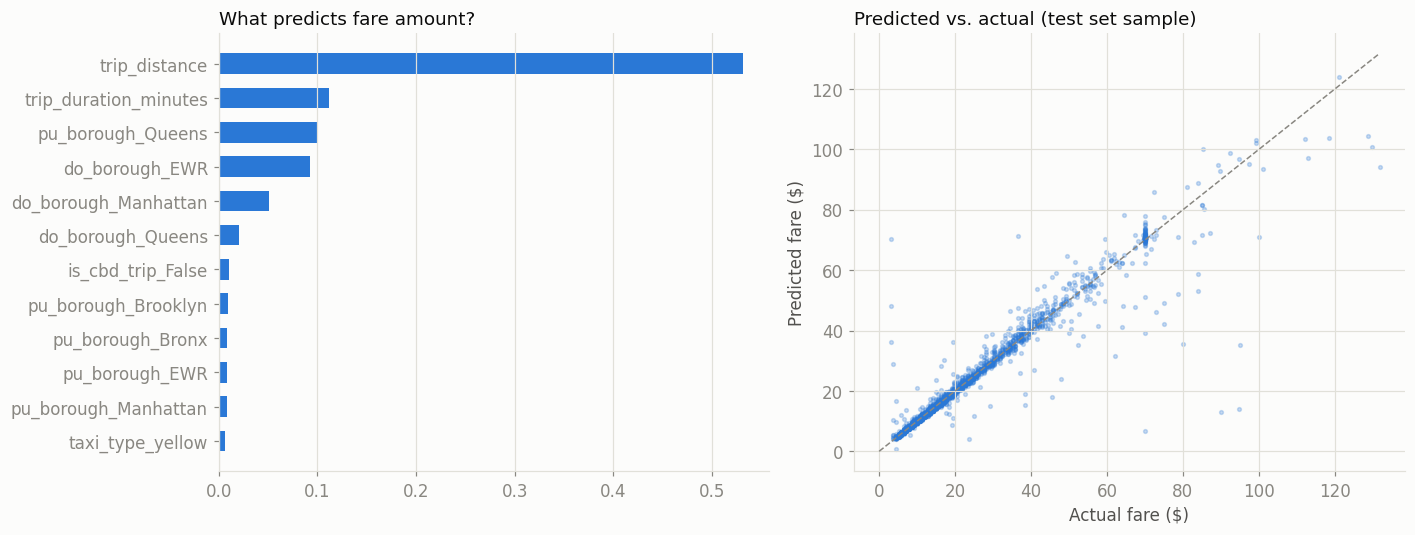

In [5]:
imp = pd.Series(xgb_model.feature_importances_, index=X_train_xgb.columns).sort_values(ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(imp.index[::-1], imp.values[::-1], color=BLUE, height=0.6)
axes[0].set_title("What predicts fare amount?", loc="left", fontsize=12, color=INK)
axes[0].grid(axis="y", visible=False)

sample = test.sample(3000, random_state=42)
sample_x = pd.get_dummies(sample[FEATURES_NUM + FEATURES_CAT], columns=FEATURES_CAT).reindex(columns=X_train_xgb.columns, fill_value=0)
sample_pred = xgb_model.predict(sample_x)
axes[1].scatter(sample.fare_amount, sample_pred, s=6, alpha=0.25, color=BLUE)
lims = [0, max(sample.fare_amount.max(), sample_pred.max())]
axes[1].plot(lims, lims, color=INK_MUTED, linewidth=1, linestyle="--")
axes[1].set_xlabel("Actual fare ($)"); axes[1].set_ylabel("Predicted fare ($)")
axes[1].set_title("Predicted vs. actual (test set sample)", loc="left", fontsize=12, color=INK)

plt.tight_layout()
plt.show()


`do_borough_EWR` and `pu_borough_Queens` both rank in the top handful of features, well ahead of most categorical dummies - the model is independently recovering the airport-flat-rate effect the earlier analysis attributed Queens' high average fare to, without being told anything about airports directly. `trip_distance` and `trip_duration_minutes` dominate overall, as expected for a metered fare.

## Residuals as an anomaly signal

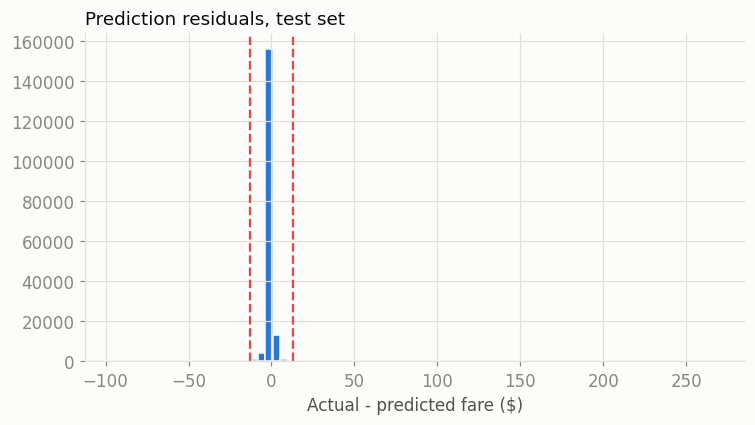

2,699 of 178,075 test trips (1.5%) have a residual beyond +/-3 standard deviations ($13.13)


In [6]:
resid = y_test.values - xgb_pred
threshold = 3 * resid.std()
n_anomalous = (np.abs(resid) > threshold).sum()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(resid, bins=80, color=BLUE, edgecolor=SURFACE)
ax.axvline(threshold, color=RED, linewidth=1.5, linestyle="--")
ax.axvline(-threshold, color=RED, linewidth=1.5, linestyle="--")
ax.set_xlabel("Actual - predicted fare ($)")
ax.set_title("Prediction residuals, test set", loc="left", fontsize=12, color=INK)
plt.tight_layout()
plt.show()

print(f"{n_anomalous:,} of {len(resid):,} test trips ({n_anomalous/len(resid)*100:.1f}%) "
      f"have a residual beyond +/-3 standard deviations (${threshold:.2f})")


## Conclusion

The model explains the large majority of fare variation (R² well above the linear baseline) using only distance, duration, time, and location - confirming fare is close to mechanically determined by trip characteristics, with location capturing flat-rate exceptions like airport runs. The ~1-2% of trips with large residuals are reasonable candidates for manual review as potential meter or data-entry errors, in the same spirit as the z-score anomaly analysis.